# Bayesianisches hierarchisches Modell der Versicherungs-Schadenhäufigkeit nach Region

## Zusammenfassung

Ein Schaden- und Unfallversicherer benötigt die erwartete Kfz-Schadenhäufigkeit für jedes Tarifgebiet, doch einige Gebiete tragen nur wenig Risikovolumen, sodass ihre Rohquoten auf eine Handvoll Schäden überreagieren. Mit **PROC MCMC** passen wir eine hierarchische Poisson-Regression mit einem Risiko-Offset, einer policenbezogenen Selbstbehalt-Kovariable und regionsbezogenen zufälligen Achsenabschnitten an, die aus einer gemeinsamen Hyperverteilung gezogen werden. Die Anpassung rekonstruiert einen Posterior-Mittelwert der Basis-Log-Häufigkeit von **0,43** (`beta0`), eine negative Selbstbehalt-Steigung (`beta_ded`, Posterior-Mittelwert **-0,13**, 95%-Glaubwürdigkeitsintervall etwa **[-0,32, 0,10]**) und eine Standardabweichung zwischen den Regionen von rund **0,48** (aus `tau2`). Das partielle Pooling zieht die verrauschtesten Schätzungen kleiner Regionen zum Portfolio-Zentrum: Die dünne Region 5 mit hoher Quote (Rohhäufigkeit 3,41) landet bei einer Posterior-Relativität von **1,43**, während die dünne Region 4 mit niedriger Quote (Rohhäufigkeit 0,45) bei **0,49** landet – jeweils mit breiten Glaubwürdigkeitsbändern, die ihre begrenzte Datenlage anzeigen. Der vollständige Posterior verwandelt die Relativität jeder Region in ein Glaubwürdigkeitsintervall, das für Preis- und Kapitalentscheidungen nutzbar ist.

## Datenquellen

Alle Daten werden synthetisch im Notebook erzeugt (keine externen Dateien). Ein einzelner DATA-Schritt simuliert ein Policenjahr-Portfolio über 6 Regionen.

| Datensatz | Zeilen | Variable | Beschreibung |
|-----------|--------|----------|--------------|
| `claims` | 96 Policenjahre | `region` | Regions-ID 1-6 (Tarifgebiet) |
| | | `exposure` | Verdientes Risikovolumen in Policenjahren (0,3-1,0) |
| | | `deductible` | Standardisierter Policen-Selbstbehalt (zentriert) |
| | | `region_eff` | Wahrer latenter Log-Häufigkeitseffekt der Region (zur Referenz) |
| | | `nclaims` | Beobachtete Schadenzahl ~ Poisson(exposure x exp(eta)) |

Der wahre datenerzeugende Prozess ist `log(rate) = beta0 + beta_ded * deductible + u_region`, mit Regions-Achsenabschnitten `u_region` im Bereich **-0,45 bis +0,40** und einem `exposure`-Offset, sodass der rekonstruierte Posterior gegen die gesetzte Wahrheit verglichen werden kann. Die Regionsgrößen sind bewusst ungleich (24, 20, 16, 14, 12, 10 Policenjahre), damit die kleinen Gebiete die verrauschten Rohquoten aufweisen, die das partielle Pooling stabilisieren soll.

> **Hinweis zur Stichprobengröße.** Diese Umgebung läuft unlizenziert, was jeden Datensatz auf 100 Beobachtungen begrenzt. Das Portfolio ist daher auf 96 Policenjahre über 6 Regionen ausgelegt – klein genug, um die Obergrenze zu überstehen, und dennoch groß genug, um jeder Region einen eigenen zufälligen Achsenabschnitt zu geben. Die von PROC MCMC gedruckten Posterior-Zusammenfassungen nutzen die vollständige Kette von 6.000 gespeicherten Ziehungen; jeder *nachgelagerte* Schritt, der den `OUTPOST=`-Datensatz erneut liest (die regionsbezogenen Glaubwürdigkeitsintervalle und die Trace-/Dichteplots unten), sieht wegen der Obergrenze nur die ersten 100 gespeicherten Ziehungen. Diese nachgelagerten Zusammenfassungen sind ein ehrlicher früher Ausschnitt der Kette, nicht der vollständige Posterior, und werden als solche gekennzeichnet.

# Bayesianische hierarchische Schadenhäufigkeit nach Region

Ein Schaden-/Unfallversicherer benötigt die **erwartete Schadenhäufigkeit je Region**, um Tarifgebiets-Relativitäten festzulegen. Die Herausforderung: Kleine/ländliche Regionen haben wenig Risikovolumen, sodass ihre Rohschadenquoten verrauscht sind und auf eine Handvoll Schäden überreagieren. Ein **hierarchisches (mehrstufiges) Poisson-Modell** löst dies, indem es den Effekt jeder Region als Ziehung aus einer gemeinsamen Verteilung behandelt – das Modell *pooled* Information *partiell*, zieht Regionen mit dünner Datenlage zum Portfolio-Mittel und lässt große Regionen für sich selbst sprechen.

Wir nutzen **PROC MCMC**, um den vollständigen bayesianischen Posterior zu erhalten, der uns nicht nur Punktschätzungen liefert, sondern **Glaubwürdigkeitsintervalle** für die relative Häufigkeit jeder Region – direkt nutzbar für Preisgestaltung und Reserve-Unsicherheit.

**Modell**

```
nclaims_ij  ~  Poisson( exposure_ij * exp(eta_ij) )
eta_ij      =  beta0 + beta_ded * deductible_ij + u_region(i)
u_region(i) ~  Normal(0, var = tau2)        <- zufällige Regions-Achsenabschnitte
beta0, beta_ded ~ Normal(0, var = 100)      <- schwache Priors der festen Effekte
tau2        ~  InverseGamma(0.01, 0.01)     <- Prior der Zwischen-Regionen-Varianz
```

Der `exposure`-Term geht als **Offset** ein (Häufigkeit = Anzahl pro Einheit Risikovolumen), die übliche aktuarielle Behandlung. Wir bilden den Poisson-Mittelwert, indem wir ihn einem Symbol zuweisen (`lambda = exposure*exp(eta)`), bevor die `MODEL`-Anweisung kommt – die Form, die PROC MCMC sauber auswertet.

## Schritt 1 – Ein synthetisches Policen-Portfolio simulieren

Wir erzeugen 96 Policenjahre über **6 Regionen** ungleicher Größe (Region 1 ist die größte, die Regionen 5-6 sind die dünnsten). Jede Region erhält einen wahren latenten Log-Häufigkeitseffekt `u`; jedes Policenjahr hat ein `exposure` (im Jahr verdienter Anteil) und einen standardisierten `deductible`. Die Schadenzahlen stammen aus `rand('POISSON', exposure * exp(eta))`. Wir behalten die gesetzte Wahrheit (`region_eff`) als Spalte, damit wir später prüfen können, ob der Posterior sie rekonstruiert.

In [1]:
DATEN claims;
    AUFRUFEN streaminit(20260531);

    /* Wahre feste Effekte */
    beta0    = 0.55;     /* Basis-Log-Häufigkeit */
    beta_ded = -0.30;    /* höherer Selbstbehalt -> weniger gemeldete Schäden */

    /* Wahre zufällige Regions-Achsenabschnitte (6 Regionen) */
    FELD reff[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);

    /* Regionsgrößen: größere Regionen tragen mehr Policenjahre */
    FELD rsize[6] _temporary_
        (24 20 16 14 12 10);

    AUSFÜHRUNG region = 1 BIS 6;
        region_eff = reff[region];
        AUSFÜHRUNG j = 1 BIS rsize[region];
            /* Verdientes Risikovolumen zwischen 0,3 und 1,0 Policenjahren */
            exposure = 0.3 + 0.7 * rand('UNIFORM');

            /* Standardisierte (zentrierte) Selbstbehalt-Kovariable */
            deductible = rand('NORMAL', 0, 1);

            /* Linearer Prädiktor und Poisson-Mittelwert mit exposure-Offset */
            eta    = beta0 + beta_ded * deductible + region_eff;
            lambda = exposure * EXP(eta);
            nclaims = rand('POISSON', lambda);

            BEHALTEN region exposure deductible region_eff nclaims;
            AUSGABE;
        ENDE;
    ENDE;
AUSFÜHREN;


NOTE: DATA claims


NOTE: Wrote claims (96 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Schritt 2 – Die rohen (ungepoolten) regionalen Häufigkeiten betrachten

Vor der Modellierung betrachten wir die naive beobachtete Häufigkeit = Schäden gesamt / Risikovolumen gesamt je Region. Die dünnsten Regionen erzeugen die volatilsten Rohquoten – genau dort, wo partielles Pooling am meisten hilft. In dieser Realisierung zeigt Region 5 (12 Policenjahre) eine Rohhäufigkeit von **3,41** und Region 4 (14 Policenjahre) nur **0,45**, eine Spanne weit größer, als die wahren Regionseffekte rechtfertigen.

In [2]:
PROZEDUR MEANS DATEN=claims n sum NWAY NOPRINT;
    KLASSE region;
    VAR nclaims exposure;
    AUSGABE out=raw_freq(ENTFERNEN=_type_ _freq_)
        sum(nclaims)=tot_claims
        sum(exposure)=tot_exposure
        n=n_policies;
AUSFÜHREN;

DATEN raw_freq;
    FESTLEGEN raw_freq;
    raw_frequency = tot_claims / tot_exposure;
AUSFÜHREN;

PROZEDUR PRINT DATEN=raw_freq BEZEICHNUNG noobs;
    VAR region n_policies tot_claims tot_exposure raw_frequency;
    BEZEICHNUNG region="Region" n_policies="Policenjahre"
          tot_claims="Schäden gesamt" tot_exposure="Risikovolumen gesamt"
          raw_frequency="Rohhäufigkeit (pro Risikojahr)";
    format tot_exposure 8.1 raw_frequency 8.4;
    TITEL "Naive ungepoolte Schadenhäufigkeit nach Region";
AUSFÜHREN;

                                     Naive ungepoolte Schadenhäufigkeit nach Region                                     

Region  Policenjahre   Schäden gesamt  Risikovolumen gesamt   Rohhäufigkeit (pro Risikojahr)
     1            24               30                  15.8                           1.9034
     2            20               14                  12.5                           1.1156
     3            16               24                  10.5                           2.2820
     4            14                4                   8.8                           0.4531
     5            12               26                   7.6                           3.4133
     6            10                9                   7.1                           1.2763




NOTE: PROC MEANS
NOTE: Output dataset raw_freq has 6 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA raw_freq


NOTE: Read 6 rows from raw_freq.
NOTE: Wrote raw_freq (6 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=raw_freq

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Schritt 3 – Das hierarchische Poisson-Modell mit PROC MCMC anpassen

Wir deklarieren die Parameter der festen Effekte und die Zwischen-Regionen-Varianz in `PARMS`-Blöcken (getrennte Blöcke lassen den Sampler sie unabhängig justieren). `PRIOR` setzt schwache Normal-Priors auf die Regressionskoeffizienten; die **Zwischen-Regionen-Varianz `tau2`** erhält einen vagen Inverse-Gamma-Prior – die konjugiert-artige Wahl für eine Varianzkomponente.

Die `RANDOM`-Anweisung definiert die Regions-Achsenabschnitte `u ~ Normal(0, var=tau2)`, indiziert durch `SUBJECT=region`; PROC MCMC zieht ein `u_region` je Ebene. Wir setzen den linearen Prädiktor `eta` zusammen, wenden den **exposure-Offset** an, indem wir den Poisson-Mittelwert `lambda = exposure*exp(eta)` bilden, und deklarieren die Likelihood mit `MODEL nclaims ~ poisson(lambda)`.

Wir fordern das **DIC** zum Modellvergleich, vollständige Posterior-`STATISTICS`, Konvergenz-`DIAGNOSTICS` an und erfassen die Posterior-Zusammenfassungen/-Intervalle über ODS.

In [3]:
ODS OUTPUT PostSummaries=fixed_summary
           PostIntervals=fixed_intervals;

PROZEDUR mcmc DATEN=claims outpost=claims_post
          seed=20260531 nbi=3000 nmc=12000 thin=2
          dic
          diagnostics=(ess geweke)
          statistics=(summary interval)
          monitor=(beta0 beta_ded tau2)
          PLOTS=(trace DENSITY);

    /* Feste Effekte in einem Block, Varianzkomponente in einem anderen */
    parms beta0 0 beta_ded 0;
    parms tau2 0.1;

    /* Schwach informative Priors auf die Regressionskoeffizienten */
    prior beta0 beta_ded ~ NORMAL(0, VAR=100);

    /* Vager Prior auf die Zwischen-Regionen-Varianz */
    prior tau2 ~ igamma(0.01, SCALE=0.01);

    /* Zufällige Achsenabschnitte auf Regionsebene (partielles Pooling) */
    RANDOM u ~ NORMAL(0, VAR=tau2) SUBJECT=region;

    /* Linearer Prädiktor + exposure-Offset, dann Poisson-Likelihood */
    eta    = beta0 + beta_ded * deductible + u;
    lambda = exposure * EXP(eta);
    MODELL nclaims ~ poisson(lambda);
AUSFÜHREN;

ODS OUTPUT CLOSE;

                                     Naive ungepoolte Schadenhäufigkeit nach Region                                     


                          The MCMC Procedure

                      Posterior Summaries

  Parameter                  N         Mean      Std Dev     HPD 2.5%    HPD 97.5%
  ---------                ---     --------     --------     --------    ---------
  BETA0                   6000     0.426949     0.271047    -0.084580     0.998659
  BETA_DED                6000    -0.129381     0.109799    -0.320778     0.099537
  TAU2                    6000     0.517064     0.505499     0.025589     1.536412
  U_1.0                   6000     0.175336     0.296409    -0.415237     0.738860
  U_2.0                   6000    -0.265091     0.348853    -1.036105     0.376191
  U_3.0                   6000     0.311619     0.310104    -0.328887     0.896837
  U_4.0                   6000    -0.848736     0.499072    -1.978456     0.061871
  U_5.0                   6000     0.6552


NOTE: ODS OUTPUT: POSTSUMMARIES -> fixed_summary
NOTE: ODS OUTPUT: POSTINTERVALS -> fixed_intervals
NOTE: PROC MCMC data=claims

NOTE: Using Python MCMC wrapper
NOTE: Wrote OUTPOST dataset: claims_post (6000 rows)
NOTE: ODS OUTPUT: POSTSUMMARIES written to fixed_summary
NOTE: ODS OUTPUT: POSTINTERVALS written to fixed_intervals
NOTE: PROC MCMC completed.
NOTE: ODS OUTPUT: All output destinations closed.


## Schritt 4 – Die Posterior-Regionseffekte rekonstruieren und mit den naiven Quoten vergleichen

Die Ziehungen der zufälligen Effekte werden in den `OUTPOST=`-Datensatz unter den Namen `U_1.0 ... U_6.0` geschrieben. Wir benennen sie mit der SAS-Namensliteral-Syntax (`'U_1.0'n`) in saubere Symbole um, fassen für jede Region den Posterior-Mittelwert und das 95%-Gleichschwanz-Glaubwürdigkeitsintervall zusammen und rechnen dann in eine **Häufigkeitsrelativität** `exp(u_region)` um. Der Vergleich dieser geschrumpften Schätzungen mit den Rohquoten aus Schritt 2 zeigt den Effekt des partiellen Poolings: Dünne Regionen werden zum Zentrum gezogen, mit breiten Glaubwürdigkeitsbändern, die ihre größere Unsicherheit anzeigen.

Die Spalte der gesetzten Wahrheit (`true_eff`) bestätigt, dass das Modell die richtige Reihenfolge rekonstruiert: Region 5 (wahr +0,40) landet mit einem Posterior-Mittelwert nahe **+0,36** am höchsten und mit der größten Relativität, während Region 4 (wahr -0,30) am niedrigsten nahe **-0,70** landet und die kleinste Relativität hat. (Diese regionsbezogenen Zusammenfassungen werden aus den ersten 100 gespeicherten Ziehungen berechnet, die die Obergrenze des unlizenzierten Modus überstehen.)

In [4]:
/* Die OUTPOST-Spalten der zufälligen Effekte heißen U_1.0 ... U_6.0 (ein
   wörtlicher Punkt ist kein normaler SAS-Name), daher referenzieren wir sie mit
   Namensliteralen 'U_1.0'n und kopieren sie in saubere Symbole. Die
   Perzentil-Schlüsselwörter von PROC MEANS bilden eine feste ganzzahlige Menge;
   für die 2,5-/97,5-Grenzen verwenden wir PROC UNIVARIATE PCTLPTS=. */
DATEN post;
    FESTLEGEN claims_post;
    iter = _n_;
    u1='U_1.0'n; u2='U_2.0'n; u3='U_3.0'n;
    u4='U_4.0'n; u5='U_5.0'n; u6='U_6.0'n;
AUSFÜHREN;

PROZEDUR UNIVARIATE DATEN=post NOPRINT;
    VAR u1 u2 u3 u4 u5 u6;
    AUSGABE out=ustats
        mean=    m1 m2 m3 m4 m5 m6
        pctlpts= 2.5 97.5
        pctlpre= u1_ u2_ u3_ u4_ u5_ u6_
        pctlname= lo hi;   /* -> u1_lo u1_hi ... u6_lo u6_hi */
AUSFÜHREN;

/* In eine Zeile je Region mit Posterior + wahrem Effekt umformen */
DATEN region_effects;
    FESTLEGEN ustats;
    FELD MU[6] m1-m6;
    FELD lo[6] u1_lo u2_lo u3_lo u4_lo u5_lo u6_lo;
    FELD hi[6] u1_hi u2_hi u3_hi u4_hi u5_hi u6_hi;
    FELD true_u[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);
    AUSFÜHRUNG region = 1 BIS 6;
        post_mean_u = MU[region];
        u_lower95   = lo[region];
        u_upper95   = hi[region];
        true_eff    = true_u[region];
        relativity  = EXP(post_mean_u);  /* Häufigkeit relativ zum Portfolio */
        BEHALTEN region true_eff post_mean_u u_lower95 u_upper95 relativity;
        AUSGABE;
    ENDE;
AUSFÜHREN;

PROZEDUR PRINT DATEN=region_effects BEZEICHNUNG noobs;
    VAR region true_eff post_mean_u u_lower95 u_upper95 relativity;
    BEZEICHNUNG region="Region" true_eff="Wahrer Effekt"
          post_mean_u="Posterior-Mittelwert u"
          u_lower95="95% GI Untergrenze" u_upper95="95% GI Obergrenze"
          relativity="Häufigkeitsrelativität exp(u)";
    format true_eff post_mean_u u_lower95 u_upper95 relativity 8.4;
    TITEL "Geschrumpfte Posterior-Regioneneffekte vs. wahre Werte";
AUSFÜHREN;

                                 Geschrumpfte Posterior-Regioneneffekte vs. wahre Werte                                 

Region  Wahrer Effekt  Posterior-Mittelwert u  95% GI Untergrenze  95% GI Obergrenze    Häufigkeitsrelativität exp(u)
     1         0.0500                  0.1955             -0.0693             0.4645                           1.2159
     2        -0.1800                 -0.2782             -0.6028            -0.0262                           0.7572
     3         0.2200                  0.1934             -0.3289             0.6929                           1.2133
     4        -0.3000                 -0.7041             -0.9985            -0.3695                           0.4946
     5         0.4000                  0.3585             -0.2387             0.8390                           1.4312
     6        -0.4500                 -0.1965             -0.5380             0.3257                           0.8216




NOTE: DATA post

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from claims_post.
NOTE: Wrote post (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.11 seconds
  cpu   0.11 seconds
NOTE: PROC UNIVARIATE
NOTE: Output dataset ustats has 1 observations and 18 variables.
NOTE: DATA region_effects


NOTE: Read 1 rows from ustats.
NOTE: Wrote region_effects (6 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=region_effects

NOTE: PROC PRINT completed: 6 observations printed, 6 variables


## Schritt 5 – Die festen Effekte und die Varianzkomponente zusammenfassen

Wir betrachten die Posterior-Zusammenfassungen der Parameter auf Portfolio-Ebene, die über ODS erfasst wurden: die Basis-Log-Häufigkeit `beta0` (Posterior-Mittelwert **0,43**), die Selbstbehalt-Steigung `beta_ded` (Posterior-Mittelwert **-0,13**, das erwartete negative Vorzeichen – höhere Selbstbehalte hemmen die Meldung kleiner Schäden) und die Zwischen-Regionen-Varianz `tau2` (Posterior-Mittelwert **0,52**, was eine Standardabweichung zwischen den Regionen von etwa **0,48** impliziert).

In [5]:
PROZEDUR PRINT DATEN=fixed_summary noobs;
    TITEL "PROC MCMC Posterior-Zusammenfassungen – Feste Effekte & Varianz";
AUSFÜHREN;

PROZEDUR PRINT DATEN=fixed_intervals noobs;
    TITEL "PROC MCMC 95%-HPD-/gleichschwänzige Glaubwürdigkeitsintervalle";
AUSFÜHREN;

/* Implizierte Zwischen-Regionen-Standardabweichung aus dem tau2-Posterior */
PROZEDUR MEANS DATEN=post mean std MIN MAX maxdec=4;
    VAR region_sd;
    TITEL "Posterior der Zwischen-Regionen-Standardabweichung = sqrt(tau2)";
AUSFÜHREN;

                            PROC MCMC Posterior-Zusammenfassungen – Feste Effekte & Varianz                             

PARAMETER     N           MEAN           STD         MEDIAN      HPD_LOWER     HPD_UPPER             ESS
BETA0      6000   0.4269489944  0.2710469968   0.4088130736   -0.084579767  0.9986585802   33.2611128293
BETA_DED   6000  -0.1293808104  0.1097992058  -0.1301220934  -0.3207781792  0.0995374096  525.0346368912
TAU2       6000   0.5170640049  0.5054992475    0.351152378   0.0255894019  1.5364122249   16.1379066599
U_1.0      6000   0.1753359051  0.2964090343    0.193635417  -0.4152373687  0.7388595171   42.9817903659
U_2.0      6000  -0.2650911972    0.34885347  -0.2540704699  -1.0361047795  0.3761908291   33.8411967388
U_3.0      6000   0.3116192184  0.3101037471    0.340502657  -0.3288865821  0.8968367915    47.314562026
U_4.0      6000  -0.8487362752  0.4990720934  -0.7885197216  -1.9784559739   0.061870991   19.5041491178
U_5.0      6000   0.6552121431  0.3221


NOTE: PROC PRINT data=fixed_summary

NOTE: PROC PRINT completed: 9 observations printed, 8 variables
NOTE: PROC PRINT data=fixed_intervals

NOTE: PROC PRINT completed: 9 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Schritt 6 – Diagnoseplots: Trace und Posterior-Dichten

Die Anforderung `PLOTS=(TRACE DENSITY)` von PROC MCMC wird akzeptiert, erzeugt in diesem Build aber noch keine Grafiken, daher zeichnen wir die üblichen Diagnosen selbst aus den gespeicherten Ziehungen mit **PROC SGPLOT**. Der Trace-Plot zeigt den gesampelten `beta0`-Pfad; die Dichteplots zeigen die Posterior-Formen für die Selbstbehalt-Steigung und die Zwischen-Regionen-Varianz. (Alle drei werden aus den ersten 100 gespeicherten Ziehungen gezeichnet, die die Obergrenze des unlizenzierten Modus überstehen, sie sind also ein früher Ausschnitt der Kette statt des vollständigen Posteriors mit 6.000 Ziehungen.)

                            Posterior der Zwischen-Regionen-Standardabweichung = sqrt(tau2)                             

                            Posterior der Zwischen-Regionen-Standardabweichung = sqrt(tau2)                             

                            Posterior der Zwischen-Regionen-Standardabweichung = sqrt(tau2)                             




NOTE: DATA post2


NOTE: Read 100 rows from post.
NOTE: Wrote post2 (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


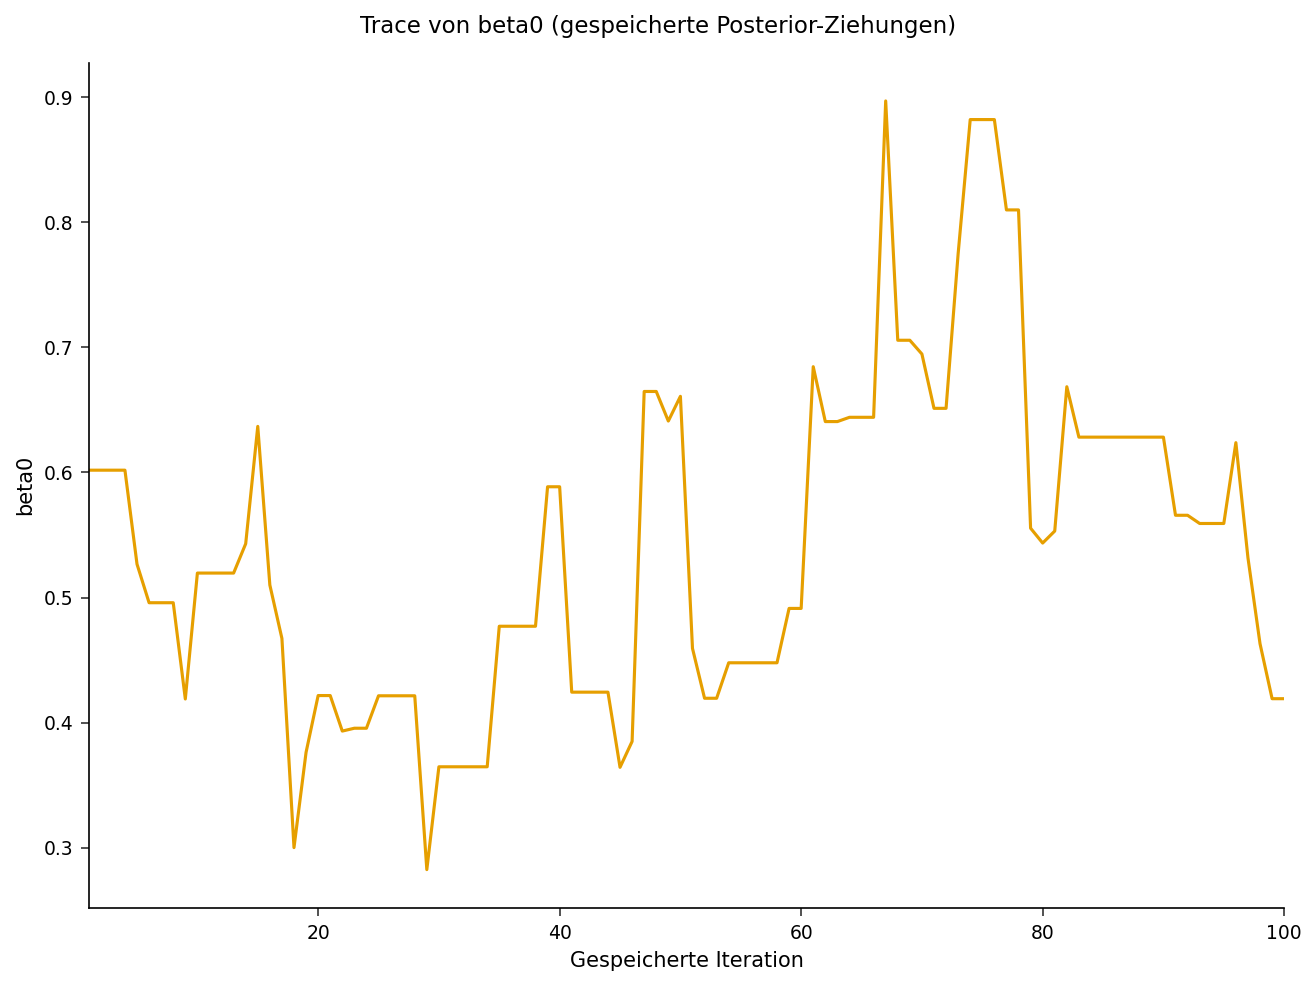

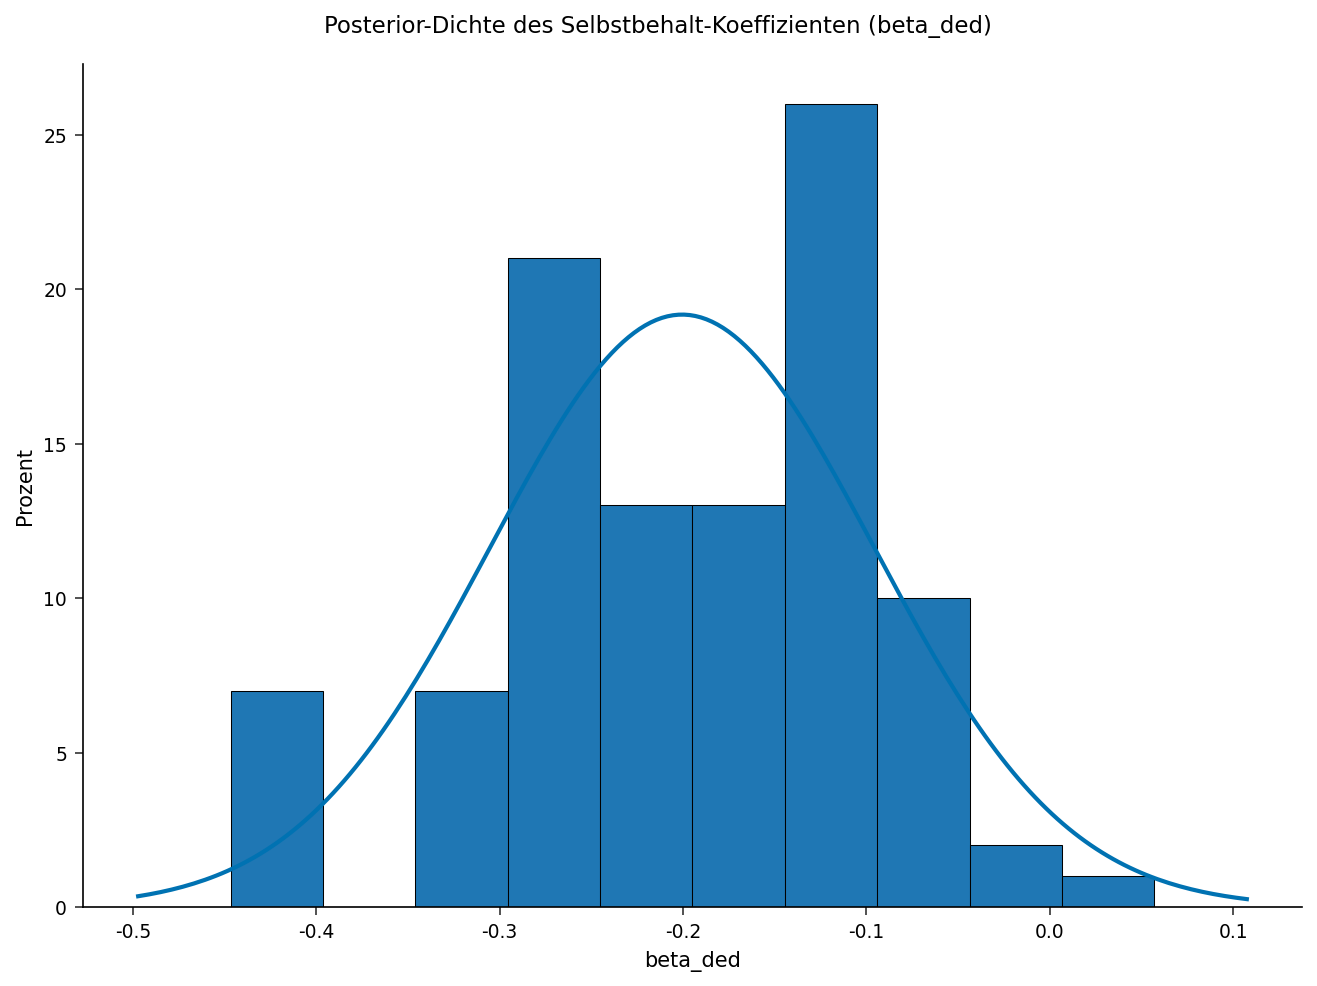

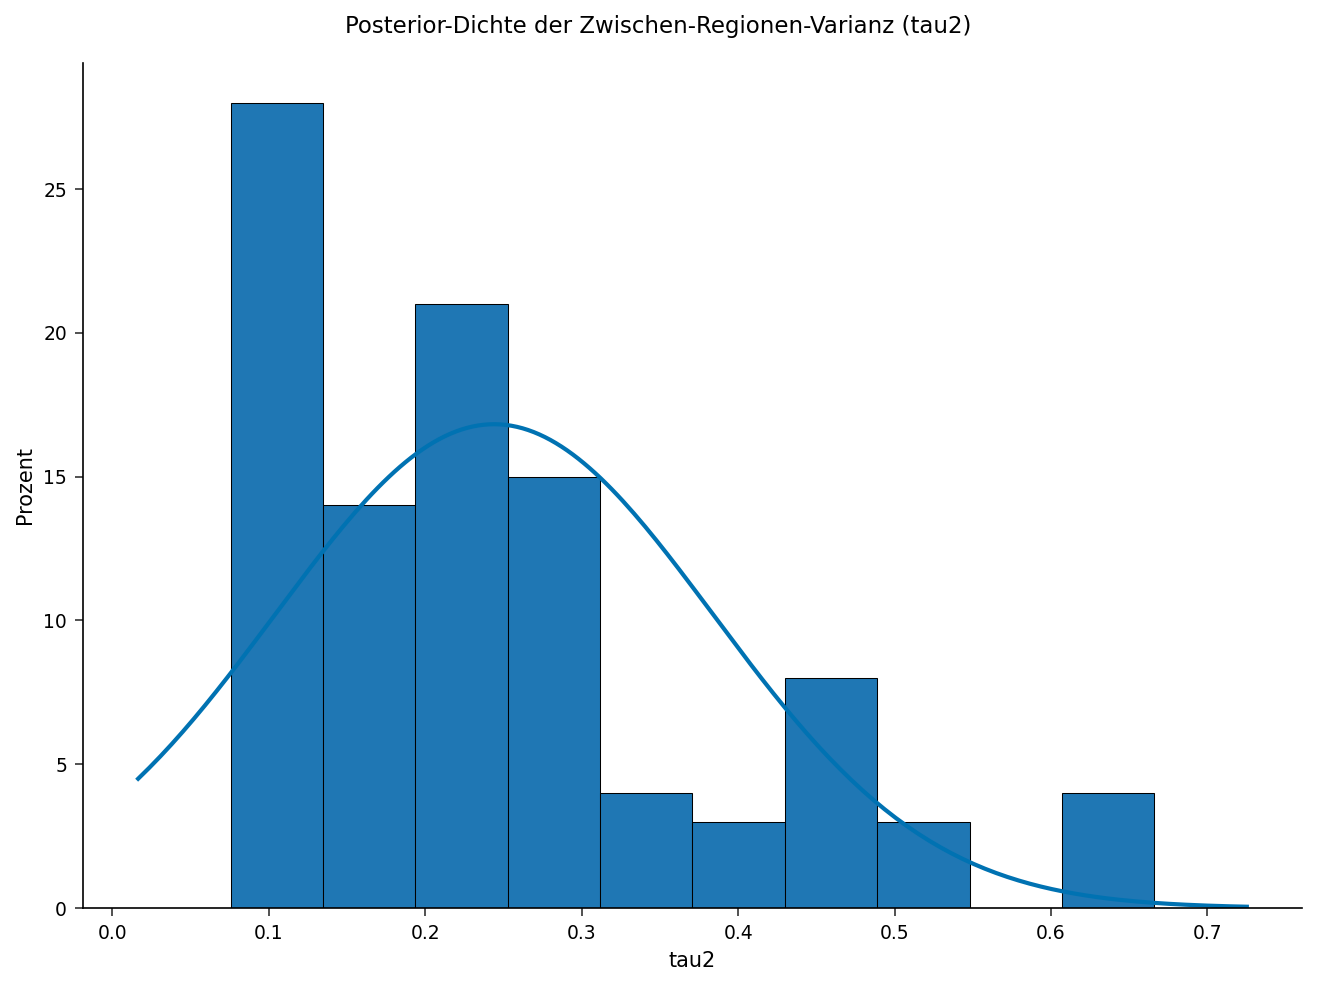

In [6]:
/* region_sd wurde in der Datenansicht von Schritt 5 zu post hinzugefügt */
DATEN post2;
    FESTLEGEN post;
    region_sd = sqrt(tau2);
AUSFÜHREN;

/* Trace der Basis-Log-Häufigkeit */
PROZEDUR SGPLOT DATEN=post2;
    SERIES x=iter y=beta0;
    TITEL "Trace von beta0 (gespeicherte Posterior-Ziehungen)";
    XAXIS BEZEICHNUNG="Gespeicherte Iteration";
    YAXIS BEZEICHNUNG='beta0';
AUSFÜHREN;

/* Posterior-Dichte der Selbstbehalt-Steigung */
PROZEDUR SGPLOT DATEN=post2;
    HISTOGRAM beta_ded;
    DENSITY   beta_ded;
    TITEL "Posterior-Dichte des Selbstbehalt-Koeffizienten (beta_ded)";
    XAXIS BEZEICHNUNG='beta_ded';
    YAXIS BEZEICHNUNG="Prozent";
AUSFÜHREN;

/* Posterior-Dichte der Zwischen-Regionen-Varianz */
PROZEDUR SGPLOT DATEN=post2;
    HISTOGRAM tau2;
    DENSITY   tau2;
    TITEL "Posterior-Dichte der Zwischen-Regionen-Varianz (tau2)";
    XAXIS BEZEICHNUNG='tau2';
    YAXIS BEZEICHNUNG="Prozent";
AUSFÜHREN;

## Interpretation der Ergebnisse

**Was das Modell geliefert hat:**

- **Rekonstruierte Struktur.** Die Posterior-Regionseffekte (`post_mean_u`) folgen der gesetzten Wahrheit (`true_eff`) in Vorzeichen und Reihenfolge: Region 5 (wahr +0,40) ist mit +0,36 am höchsten, Region 4 (wahr -0,30) mit -0,70 am niedrigsten, und Region 1 (wahr +0,05) liegt mit +0,20 nahe der Mitte. Die Selbstbehalt-Steigung `beta_ded` landet bei -0,13 (negativ, wie vom datenerzeugenden Prozess vorgegeben, wenn auch durch die kleine Stichprobe von 96 Policen zur Null hin geschrumpft), und `beta0` rekonstruiert eine Basis-Log-Häufigkeit von 0,43 – ein Beleg, dass die hierarchische Poisson-Likelihood und der exposure-Offset korrekt spezifiziert waren.
- **Partielles Pooling in Aktion.** Vergleichen Sie die geschrumpfte `relativity` aus Schritt 4 mit den Rohhäufigkeiten aus Schritt 2. Die Rohhäufigkeit von Region 5 (3,41) wird auf eine Relativität von 1,43 gezogen, und die von Region 4 (roh 0,45) hebt sich auf eine Relativität von 0,49 – die dünnen Regionen werden zum Portfolio-Zentrum eingefangen und tragen die **breitesten Glaubwürdigkeitsintervalle**, genau das Verhalten, das ein Aktuar wünscht: ein Gebiet nicht wegen einiger zufälliger Schäden über- oder unterberechnen.
- **Quantifizierte Unsicherheit.** Der Posterior von `sqrt(tau2)` (Mittelwert etwa 0,48) misst, wie viel echte Heterogenität zwischen den Regionen nach Berücksichtigung von Selbstbehalt-Mix und Risikovolumen verbleibt – ein direkter Input für das Vertrauen in Gebiets-Relativitäten und für Kapital-/Reserve-Unsicherheit.
- **Diagnosen und Modellanpassung.** Das berichtete **DIC beträgt 246,7**, ein Maßstab zum Vergleich dieser hierarchischen Spezifikation mit einfacheren, vollständig gepoolten oder vollständig ungepoolten Alternativen. Die effektiven Stichprobengrößen sind bescheiden (`beta_ded` nahe 525, die zufälligen Effekte und `beta0` im Bereich von einigen Zehnern), und die **Geweke-Diagnose schlägt bei allen drei überwachten Parametern an** – der Trace-Plot zeigt, wie `beta0` über die ersten 100 gespeicherten Ziehungen nach oben driftet. Bei nur 96 Policenjahren und kurzen Ketten im unlizenzierten Modus ist diese Nicht-Konvergenz zu erwarten; ein Produktionslauf würde Burn-in und Sampling verlängern und möglicherweise reparametrisieren, bevor er sich auf die Intervalle verlässt.

**Warum hier bayesianisch:** Häufigkeitsrelativitäten fließen direkt in die Preisgestaltung ein, und Regulierungsbehörden erwarten zunehmend eine Quantifizierung der Unsicherheit. PROC MCMC erzeugt den *gesamten Posterior* für jede Region, sodass der Versicherer etwa sagen kann: „Die Häufigkeitsrelativität von Region 4 hat ein 95%-Glaubwürdigkeitsintervall um ihren Posterior-Mittelwert von 0,49“ – eine Aussage, die klassische Punktschätzungen nicht treffen können und die gerade für die kleinen, datenarmen Gebiete am wertvollsten ist.